In [1]:
!pip install mglearn

  Using cached mglearn-0.2.0-py2.py3-none-any.whl.metadata (628 bytes)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached imageio-2.37.4-py3-none-any.whl.metadata (9.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached mglearn-0.2.0-py2.py3-none-any.whl (581 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached imageio-2.37.4-py3-none-any.whl (318 kB)
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.2 MB 11.2 MB/s eta 0:00:01
   -------------------- ------------------- 3.7/7.2 MB 9.9 MB/s eta 0:00:01
   ---------------------------------- ----- 6.3/7.2 MB 10.4 MB/s eta 0:00:01
   ---

In [4]:
 !pip install tensorflow

In [4]:
!pip install scikit-learn

In [7]:
import numpy as np 
import matplotlib.pyplot as plt 
import mglearn 
import tensorflow as tf
from sklearn.datasets import fetch_lfw_people 
from sklearn.model_selection import train_test_split 
from sklearn.decomposition import PCA 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.preprocessing import MinMaxScaler 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, Dense

In [8]:
np.random.seed(180) 
tf.random.set_seed(180) 

In [9]:
people = fetch_lfw_people(min_faces_per_person=20,resize=0.7) 
print(people.data.shape) 
print(people.target.shape) 
image_shape = people.images[0].shape 

(3023, 5655)
(3023,)


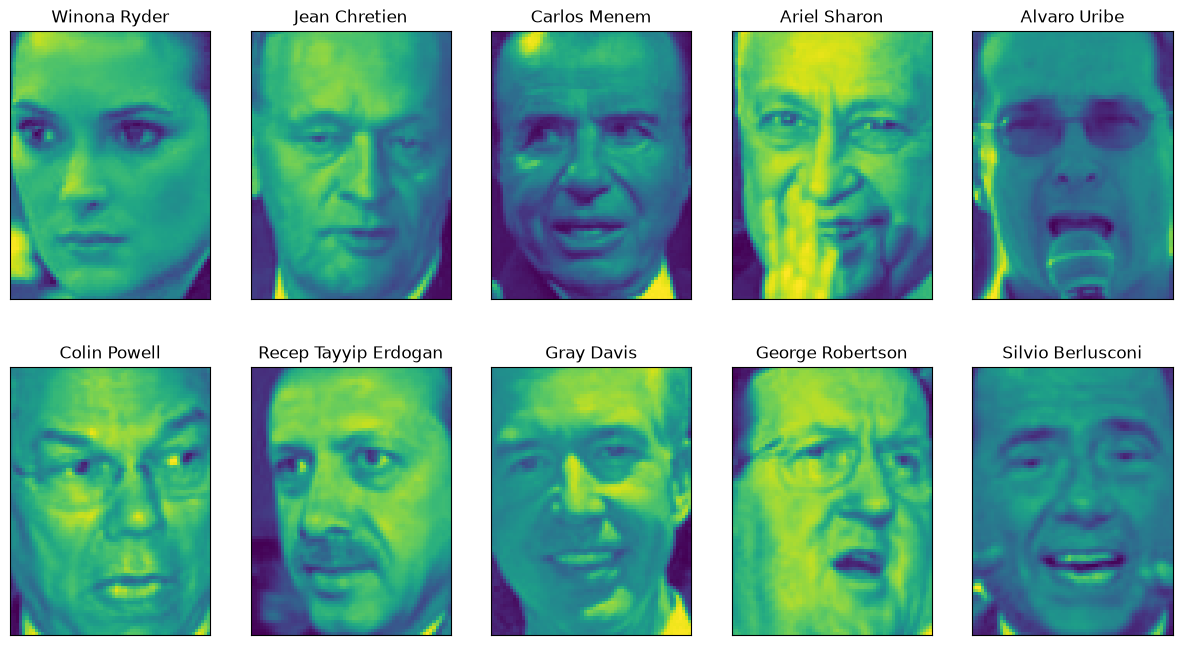

In [15]:
fix, axes = plt.subplots(2,5,figsize=(15,8),subplot_kw={'xticks':(), 'yticks':()}) 
for target, image, ax in zip(people.target,people.images,axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target]) 
plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(people.data,people.target, test_size=0.2, random_state=20) 
y_train = y_train.astype(int) 
y_test = y_test.astype(int) 
batch_size = len(X_train) 
print(X_train.shape,y_train.shape,y_test.shape) 
print("people.images.shape: {}".format(people.images.shape)) 
print("Number of classes: {}".format(len(people.target_names))) 

(2418, 5655) (2418,) (605,)
people.images.shape: (3023, 87, 65)
Number of classes: 62


In [18]:
count = np.bincount(people.target) 
for i, (count, name) in enumerate(zip(count, people.target_names)): 
    print( "{0:25} {1:3}".format(name,count),end=" ") 
    if (i+1)%3 == 0: 
        print()

Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Angelina Jolie             20 Ariel Sharon               77 
Arnold Schwarzenegger      42 Atal Bihari Vajpayee       24 Bill Clinton               29 
Carlos Menem               21 Colin Powell              236 David Beckham              31 
Donald Rumsfeld           121 George Robertson           22 George W Bush             530 
Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 
Guillermo Coria            30 Hamid Karzai               22 Hans Blix                  39 
Hugo Chavez                71 Igor Ivanov                20 Jack Straw                 28 
Jacques Chirac             52 Jean Chretien              55 Jennifer Aniston           21 
Jennifer Capriati          42 Jennifer Lopez             21 Jeremy Greenstock          24 
Jiang Zemin                20 John Ashcroft              53 John Negroponte            31 

In [19]:
mask = np.zeros(people.target.shape,dtype=np.bool_) 
for target in np.unique(people.target): 
    mask[np.where(people.target == target)[0][:50]] = True 
X_people = people.data[mask] 
y_people = people.target[mask]  
X_people = X_people / 255.0 

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_people,y_people,stratify=y_people,random_state=0) 
knn = KNeighborsClassifier(n_neighbors=1) 
knn.fit( X_train, y_train) 
print( "Test set score of 1-nn: {:.2f}".format(knn.score(X_test,y_test)))

Test set score of 1-nn: 0.22


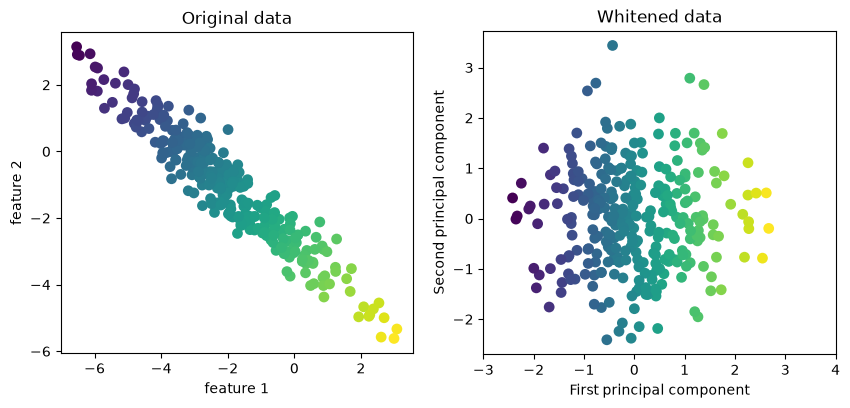

In [22]:
mglearn.plots.plot_pca_whitening() 
plt.show() 

In [25]:
pca = PCA(n_components=100,whiten=True,random_state=0).fit(X_train) 
X_train_pca = pca.transform(X_train) 
X_test_pca = pca.transform(X_test) 
print("X_train_pca.shape: {}".format(X_train_pca.shape)) 
# KNN with PCA 
knn = KNeighborsClassifier(n_neighbors=1) 
knn.fit(X_train_pca,y_train) 
print("Test set accuracy: {:.2f}".format(knn.score(X_test_pca,y_test))) 
print("pca.components_.shape: {}".format(pca.components_.shape)) 

X_train_pca.shape: (1547, 100)
Test set accuracy: 0.30
pca.components_.shape: (100, 5655)


In [26]:
scaler = MinMaxScaler() 
X_train_scaled = scaler.fit_transform( X_train_pca) 
X_test_scaled = scaler.transform(X_test_pca)

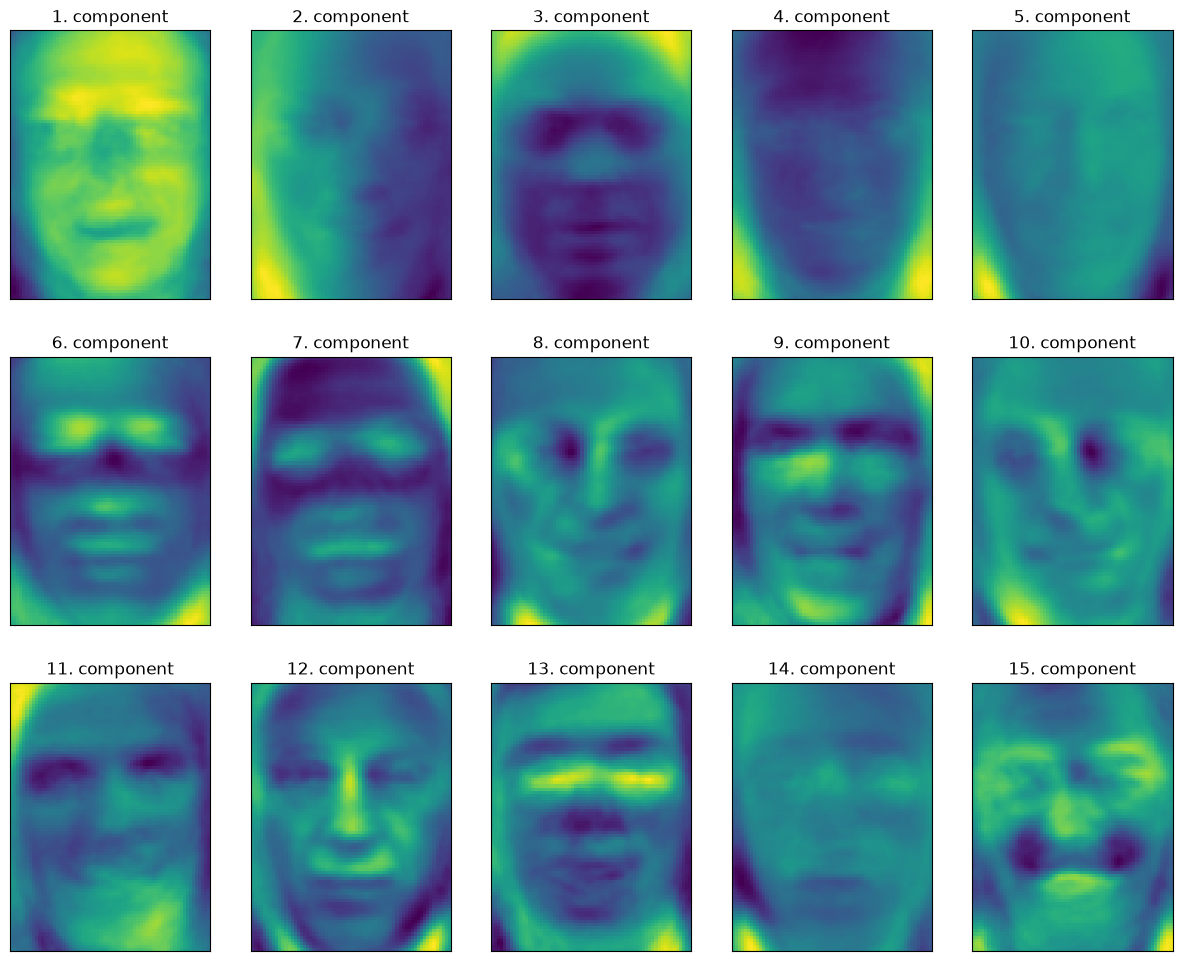

In [30]:
fix, axes = plt.subplots(3,5,figsize=(15,12), subplot_kw={'xticks':(), 'yticks':()}) 
for i, (component, ax) in enumerate(zip(pca.components_, axes.ravel())): 
    ax.imshow(component.reshape(image_shape),cmap='viridis') 
    ax.set_title("{}. component".format(i+1)) 
plt.show() 

In [31]:
scaler = MinMaxScaler() 
X_train_scaled = scaler.fit_transform( X_train_pca) 
X_test_scaled = scaler.transform(X_test_pca)

In [40]:
model = Sequential([Input(shape=(100,)),Dense(300,activation='relu'),Dense(100,activation='relu'),Dense( len(np.unique(y_train)),activation='softmax')]) 

In [42]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [45]:
history = model.fit( X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False, verbose=1) 

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0194 - loss: 4.1275
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0271 - loss: 4.0895
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0259 - loss: 4.0670
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0368 - loss: 4.0467
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0414 - loss: 4.0228
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0543 - loss: 3.9938
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0737 - loss: 3.9604
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0963 - loss: 3.9185
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1202 - loss: 3.8649
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1377 - loss: 3.7962
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1622 - loss: 3.7119
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1771 - lo

In [46]:
loss, accuracy = model.evaluate( X_test_scaled,y_test,verbose=1) 
print("Test Loss:", loss) 
print("Test Accuracy:", accuracy) 

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2539 - loss: 2.9238
Test Loss: 2.923835515975952
Test Accuracy: 0.2538759708404541
